In [38]:
import tensorflow as tf

import matplotlib
from matplotlib import pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

matplotlib.rcParams['figure.figsize'] = [9, 6]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


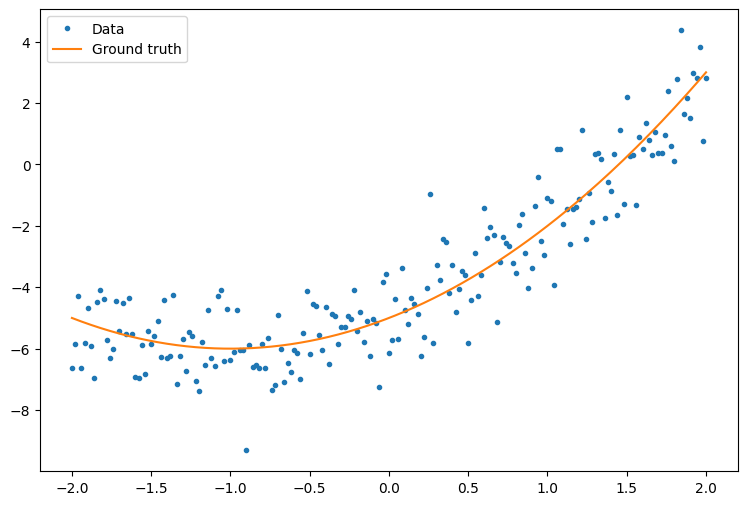

In [39]:
# 1. PREPARACIÓN DE DATOS

x = tf.linspace(-2, 2, 201)
x = tf.cast(x, tf.float32)

def f(x):
  y = x**2 + 2*x - 5
  return y

y = f(x) + tf.random.normal(shape=[201])

plt.plot(x.numpy(), y.numpy(), '.', label='Data')
plt.plot(x, f(x),  label='Ground truth')
plt.legend();

In [40]:
# 2. DEFINICIÓN DEL MODELO

class Model(tf.keras.Model):
  def __init__(self, units, **kwargs): # **kwargs para compatibilidad
    super().__init__(**kwargs)
    self.units = units # Guardamos units como atributo
    self.dense1 = tf.keras.layers.Dense(units=units,
                                        activation=tf.nn.relu,
                                        kernel_initializer=tf.random.normal,
                                        bias_initializer=tf.random.normal)
    self.dense2 = tf.keras.layers.Dense(1)

  def call(self, x, training=True):
    # For Keras layers/models, implement `call` instead of `__call__`.
    x = x[:, tf.newaxis]
    x = self.dense1(x)
    x = self.dense2(x)
    return tf.squeeze(x, axis=1)

  # --- IMPORTANTE ---
  def get_config(self):
    config = super().get_config()
    config.update({
      "units": self.units,
    })
    return config
  # -------------------

In [41]:
model = Model(64)

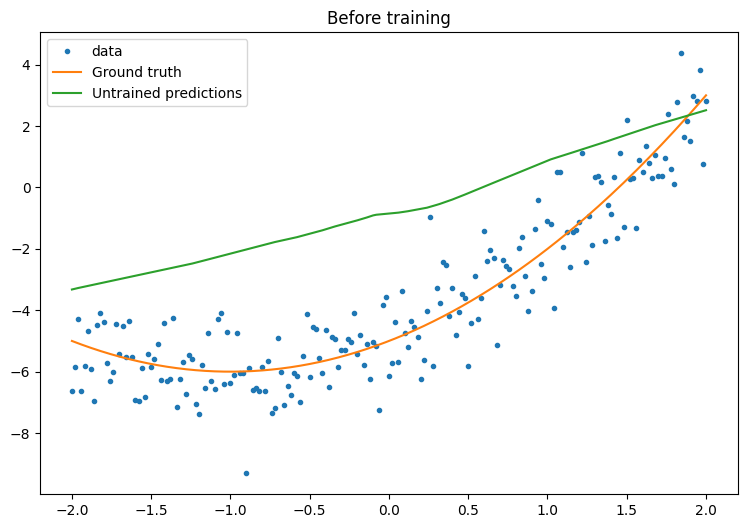

In [42]:
plt.plot(x.numpy(), y.numpy(), '.', label='data')
plt.plot(x, f(x),  label='Ground truth')
plt.plot(x, model(x), label='Untrained predictions')
plt.title('Before training')
plt.legend();

In [43]:
# 4. BUCLE DE ENTRENAMIENTO

variables = model.variables

optimizer = tf.optimizers.SGD(learning_rate=0.01)

for step in range(1000):
  with tf.GradientTape() as tape:
    prediction = model(x)
    error = (y-prediction)**2
    mean_error = tf.reduce_mean(error)
  gradient = tape.gradient(mean_error, variables)
  optimizer.apply_gradients(zip(gradient, variables))

  if step % 100 == 0:
    print(f'Mean squared error: {mean_error.numpy():0.3f}')

Mean squared error: 11.386
Mean squared error: 1.124
Mean squared error: 1.105
Mean squared error: 1.090
Mean squared error: 1.080
Mean squared error: 1.072
Mean squared error: 1.065
Mean squared error: 1.060
Mean squared error: 1.055
Mean squared error: 1.052


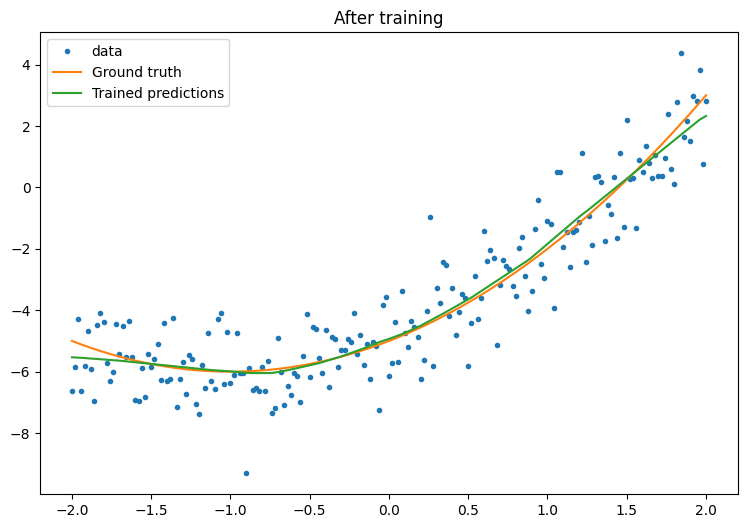

In [44]:
plt.plot(x.numpy(),y.numpy(), '.', label="data")
plt.plot(x, f(x),  label='Ground truth')
plt.plot(x, model(x), label='Trained predictions')
plt.title('After training')
plt.legend();

In [45]:
new_model = Model(64)

Modelo guardado exitosamente.


Text(0.5, 1.0, 'Keras training progress')

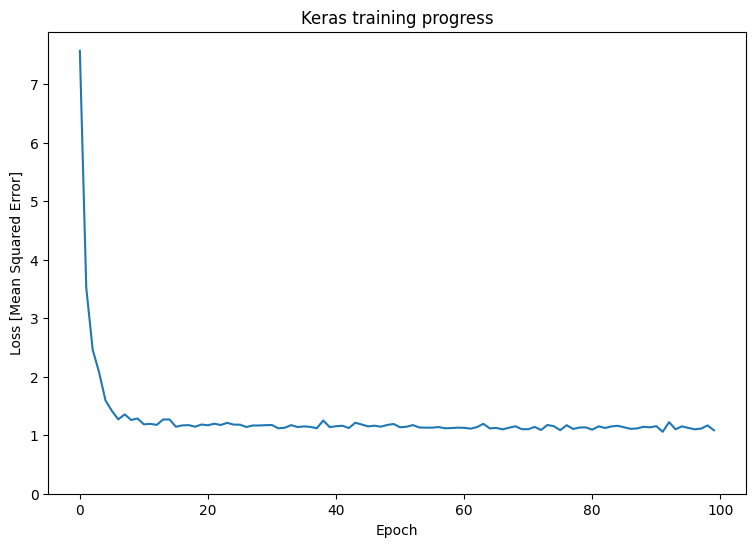

In [46]:
# ----
new_model = Model(64)
# ----
new_model.compile(
    loss=tf.keras.losses.MSE,
    optimizer=tf.optimizers.SGD(learning_rate=0.01))

history = new_model.fit(x, y,
                        epochs=100,
                        batch_size=32,
                        verbose=0)

import os

# 1. Definir la ruta de la carpeta
save_dir = '/content/drive/MyDrive/modelos'

# 2. Crear la carpeta si no existe
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    print(f"Carpeta creada en: {save_dir}")

# 3. Guardar el modelo
model.save(os.path.join(save_dir, 'my_model.keras'))
print("Modelo guardado exitosamente.")

# Guardar directamente en tu Drive
# model.save('/content/drive/MyDrive/modelos/my_model.keras')
# ----
plt.plot(history.history['loss'])
plt.xlabel('Epoch')
plt.ylim([0, max(plt.ylim())])
plt.ylabel('Loss [Mean Squared Error]')
plt.title('Keras training progress')